In [ ]:
# @title
!pip install datasets -q

In [5]:
import re
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import load_dataset
from sklearn.feature_extraction.text import CountVectorizer

# Load the IMDB dataset. We explicitly select only the 'train' and 'test'
# splits (25k reviews each) to get exactly 50k labeled examples.
dataset = load_dataset("imdb")
df = pd.concat([pd.DataFrame(dataset[split]) for split in ["train", "test"]])
df = df.reset_index(drop=True)

# Map numeric labels to human-readable sentiment strings for cleaner plots
df['sentiment'] = df['label'].map({0: 'negative', 1: 'positive'})
print(f"Total reviews loaded: {len(df)}")
df.head()

Total reviews loaded: 50000


,text,label,sentiment
0,I rented I AM CURIOUS-YELLOW from my video sto...,0,negative
1,"""I Am Curious: Yellow"" is a risible and preten...",0,negative
2,If only to avoid making this type of film in t...,0,negative
3,This film was probably inspired by Godard's Ma...,0,negative
4,"Oh, brother...after hearing about this ridicul...",0,negative


In [6]:
def clean_html(text):
    """Strip HTML tags (e.g. <br />) and collapse extra whitespace."""
    text = re.sub(r'<[^>]*?>', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

print("Cleaning HTML tags...")
df['cleaned_text'] = df['text'].apply(clean_html)

# Sanity check: preview one review before and after cleaning
print("Original:", df['text'].iloc[0][:100], "...")
print("Cleaned: ", df['cleaned_text'].iloc[0][:100], "...")

Cleaning HTML tags...
Original: I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it w ...
Cleaned:  I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it w ...


/tmp/ipykernel_355/3966073186.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=df, palette='viridis')


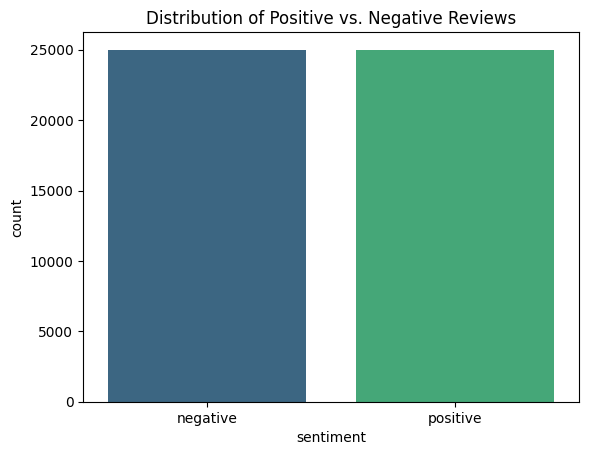

sentiment
negative    25000
positive    25000
Name: count, dtype: int64


In [7]:
# Confirm the dataset is balanced (equal positive and negative reviews)
sns.countplot(x='sentiment', data=df, palette='viridis')
plt.title('Distribution of Positive vs. Negative Reviews')
plt.show()

print(df['sentiment'].value_counts())

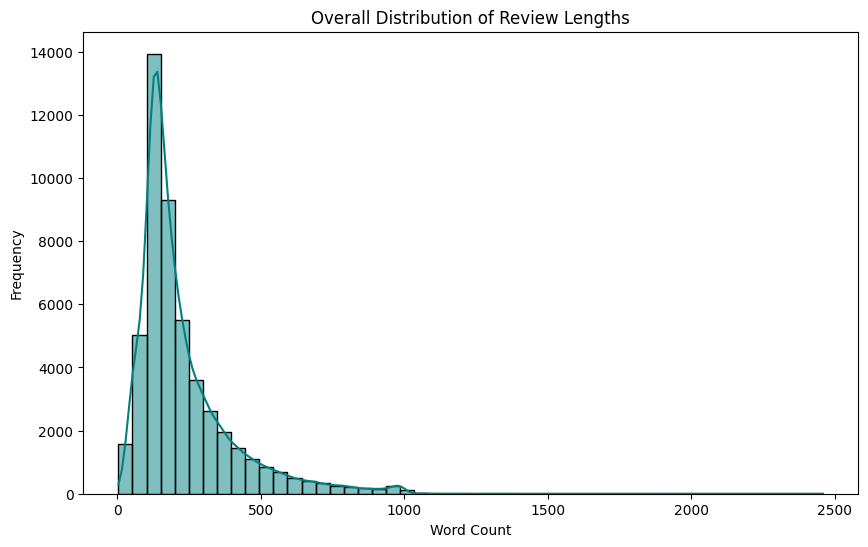

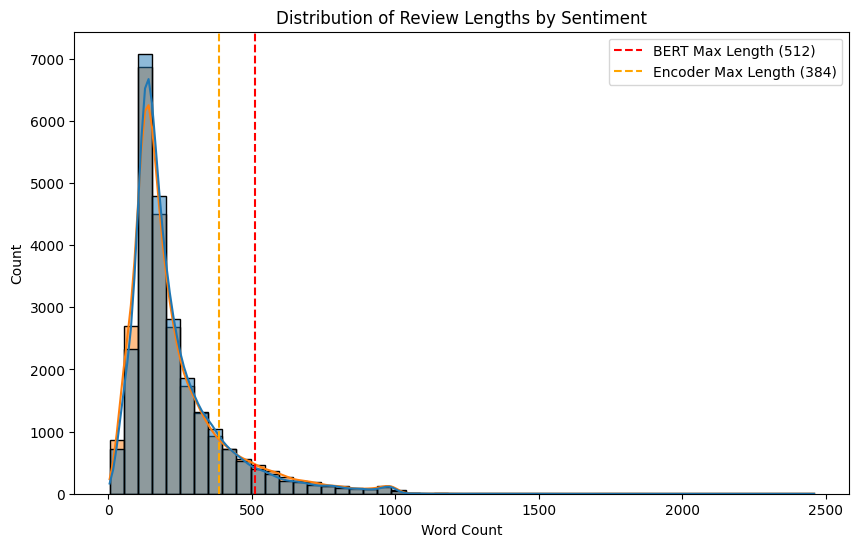

Percentage of reviews longer than 512 words: 7.20%
Percentage of reviews longer than 384 words: 13.74%


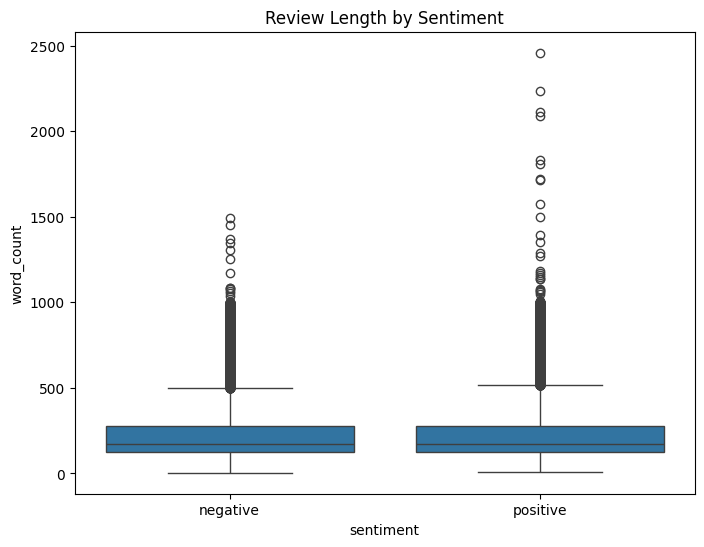

In [8]:
df['word_count'] = df['cleaned_text'].apply(lambda x: len(x.split()))

# Overall word count distribution (no sentiment split)
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='word_count', kde=True, bins=50, color='teal')
plt.title('Overall Distribution of Review Lengths')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.show()

# Word count distribution by sentiment, with both common truncation thresholds
# annotated so we can assess how much content would be lost at each limit.
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='word_count', hue='sentiment', kde=True, bins=50)
plt.axvline(x=512, color='red',    linestyle='--', label='BERT Max Length (512)')
plt.axvline(x=384, color='orange', linestyle='--', label='Encoder Max Length (384)')
plt.title('Distribution of Review Lengths by Sentiment')
plt.xlabel('Word Count')
plt.legend()
plt.show()

# Report the percentage of reviews that exceed each threshold
for threshold in [512, 384]:
    pct = (df['word_count'] > threshold).mean() * 100
    print(f"Percentage of reviews longer than {threshold} words: {pct:.2f}%")

# Box plot to compare length distributions across sentiment classes
plt.figure(figsize=(8, 6))
sns.boxplot(x='sentiment', y='word_count', data=df)
plt.title("Review Length by Sentiment")
plt.show()

In [9]:
# Define aggregation metrics once and reuse for both overall and per-sentiment stats
metrics = [
    ('Mean',            'mean'),
    ('Median',          'median'),
    ('Std',             'std'),
    ('Min',             'min'),
    ('Max',             'max'),
    ('25th percentile', lambda x: x.quantile(0.25)),
    ('75th percentile', lambda x: x.quantile(0.75)),
]

overall       = df['word_count'].agg(dict(metrics))
per_sentiment = df.groupby('sentiment')['word_count'].agg(metrics)

print("--- Overall Word Count Statistics ---")
print(overall)

# Transpose so positive/negative appear as columns for easy side-by-side comparison
print("\n--- Word Count Statistics per Sentiment ---")
print(per_sentiment.T)

--- Overall Word Count Statistics ---
Mean                228.865940
Median              171.000000
Std                 169.589105
Min                   4.000000
Max                2459.000000
25th percentile     125.000000
75th percentile     278.000000
Name: word_count, dtype: float64

--- Word Count Statistics per Sentiment ---
sentiment           negative     positive
Mean              227.110000   230.621880
Median            172.000000   171.000000
Std               163.178988   175.751332
Min                 4.000000    10.000000
Max              1491.000000  2459.000000
25th percentile   127.000000   124.000000
75th percentile   275.000000   280.000000


In [10]:
# Fit a vocabulary over the full corpus to get a sense of total unique terms
vectorizer = CountVectorizer(stop_words='english', max_features=100000)
vectorizer.fit(df['cleaned_text'])
print("Vocabulary size:", len(vectorizer.vocabulary_))

def get_top_ngram(corpus, n=1, top_k=10):
    """
    Return the top_k most frequent n-grams from corpus after removing
    English stop words. Uses a bag-of-words representation internally.
    """
    vec = CountVectorizer(
        ngram_range=(n, n),
        stop_words='english',
        lowercase=True,
        max_features=50000,
    )
    bag_of_words = vec.fit_transform(corpus)
    sum_words     = bag_of_words.sum(axis=0)
    words_freq    = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq    = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:top_k]

Vocabulary size: 100000


In [11]:
pos_corpus = df[df['label'] == 1]['cleaned_text']
neg_corpus = df[df['label'] == 0]['cleaned_text']

top_unigrams_overall = get_top_ngram(df['cleaned_text'].tolist(), n=1, top_k=10)
top_pos_unigrams     = get_top_ngram(pos_corpus.tolist(), n=1)
top_neg_unigrams     = get_top_ngram(neg_corpus.tolist(), n=1)

print("\nTop Unigrams Overall:")
for word, freq in top_unigrams_overall:
    print(f"  {word}: {freq}")

print("\nTop Positive Unigrams:", top_pos_unigrams)
print("Top Negative Unigrams:", top_neg_unigrams)


Top Unigrams Overall:
  movie: 87970
  film: 79705
  like: 40172
  just: 35183
  good: 29753
  time: 25109
  story: 23119
  really: 23094
  bad: 18473
  people: 18188

Top Positive Unigrams: [('film', np.int64(42110)), ('movie', np.int64(37854)), ('like', np.int64(17714)), ('good', np.int64(15025)), ('just', np.int64(14109)), ('great', np.int64(12964)), ('story', np.int64(12934)), ('time', np.int64(12752)), ('really', np.int64(10739)), ('people', np.int64(8719))]
Top Negative Unigrams: [('movie', np.int64(50116)), ('film', np.int64(37595)), ('like', np.int64(22458)), ('just', np.int64(21074)), ('good', np.int64(14728)), ('bad', np.int64(14726)), ('time', np.int64(12357)), ('really', np.int64(12355)), ('don', np.int64(10622)), ('story', np.int64(10185))]


In [12]:
top_bigrams     = get_top_ngram(df['cleaned_text'].tolist(), n=2)
top_pos_bigrams = get_top_ngram(pos_corpus, n=2)
top_neg_bigrams = get_top_ngram(neg_corpus, n=2)

print("\nTop Bigrams Overall:", top_bigrams)
print("Top Positive Bigrams:", top_pos_bigrams)
print("Top Negative Bigrams:", top_neg_bigrams)


Top Bigrams Overall: [('ve seen', np.int64(4168)), ('special effects', np.int64(2249)), ('don know', np.int64(2202)), ('low budget', np.int64(1824)), ('looks like', np.int64(1678)), ('year old', np.int64(1598)), ('movie just', np.int64(1538)), ('waste time', np.int64(1526)), ('good movie', np.int64(1515)), ('sci fi', np.int64(1393))]
Top Positive Bigrams: [('ve seen', np.int64(1861)), ('don know', np.int64(899)), ('new york', np.int64(855)), ('special effects', np.int64(807)), ('good movie', np.int64(762)), ('real life', np.int64(761)), ('years ago', np.int64(741)), ('10 10', np.int64(734)), ('great movie', np.int64(723)), ('year old', np.int64(684))]
Top Negative Bigrams: [('ve seen', np.int64(2307)), ('waste time', np.int64(1453)), ('special effects', np.int64(1442)), ('don know', np.int64(1303)), ('looks like', np.int64(1259)), ('low budget', np.int64(1230)), ('movie just', np.int64(1074)), ('look like', np.int64(961)), ('bad movie', np.int64(926)), ('year old', np.int64(914))]
